# Study of Oxide Defects in a MOSFET
## 1/f Noise Analysis — McWhorter Model

**Course:** Modeling and Simulation of Advanced Electronic Devices  
**Objective:** Extract the oxide trap density $N_T(E_f)_{eff}$ from drain current noise measurements.

---

## 1. Theoretical Background

### 1.1 Origin of 1/f Noise in MOSFETs

Flicker (1/f) noise in MOS transistors originates from the **trapping and release** of inversion-layer carriers by traps located in the gate oxide, near the Si-SiO₂ interface. According to the microscopic model of **Van der Ziel**, the tunnel interaction between channel electrons and oxide traps, uniformly distributed in depth, produces a superposition of Lorentzian spectra that results in a $1/f$-type spectrum.

The power spectral density of carrier number fluctuations in a channel section $\Delta x$:

$$S_{\Delta N}(x, f) = \frac{N_T(E_f)_{eff} \cdot kT \cdot w \cdot \Delta x}{\gamma \cdot f}$$

### 1.2 McWhorter Model Without Mobility Correlation

The flat-band voltage spectral density:

$$S_{V_{FB}} = S_{V_{GS}} = \frac{q^2 \cdot N_T(E_f)_{eff} \cdot kT}{W \cdot L \cdot C_{ox}^2 \cdot \gamma \cdot f}$$

And the normalized drain current spectral density:

$$\frac{S_{I_d}}{I_d^2} = \frac{g_m^2}{I_d^2} \cdot S_{V_{FB}}$$

### 1.3 Model With Mobility Correlation

$$\frac{S_{I_d}}{I_d^2} = \left(1 \pm \alpha \mu_{eff} C_{ox} \frac{I_d}{g_m}\right)^2 \frac{g_m^2}{I_d^2} \cdot S_{V_{FB}}$$

where $\alpha \sim 10^4$ Vs/C is the mobility correlation parameter.

## 2. Environment Setup and Device Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 100
})

# DEVICE PARAMETERS
mu    = 1500e-4       # mobility [m²/Vs]
t_ox  = 34e-9         # oxide thickness [m]
eps_0 = 8.854e-12     # vacuum permittivity [F/m]
eps_r = 3.9           # relative permittivity SiO₂
C_ox  = eps_0 * eps_r / t_ox  # oxide capacitance [F/m²]
gamma = 1e10          # tunneling parameter [m⁻¹]
W     = 84e-6         # channel width [m]
L     = 1.0e-6        # channel length [m]
q     = 1.602e-19     # electron charge [C]
kT    = 1.381e-23 * 300  # kT at 300 K [J]

print('=== MOSFET Parameters ===')
print(f'  μ     = {mu*1e4:.0f} cm²/Vs')
print(f'  t_ox  = {t_ox*1e9:.0f} nm')
print(f'  C_ox  = {C_ox*1e4:.4e} F/cm²')
print(f'  γ     = {gamma:.0e} m⁻¹')
print(f'  W×L   = {W*L*1e12:.0f} μm²')
print(f'  kT    = {kT:.4e} J  ({kT/q*1e3:.1f} meV)')

=== Parámetros del MOSFET ===
  μ     = 1500 cm²/Vs
  t_ox  = 34 nm
  C_ox  = 1.0156e+01 F/cm²
  γ     = 1e+10 m⁻¹
  W×L   = 84 μm²
  kT    = 4.1430e-21 J  (25.9 meV)


## 3. Loading Experimental Data

Experimental setup:
1. **Source $V_{GG}$** → controls $V_{GS}$
2. **Source $V_{DD}$** with $V_{DS} \approx 50$ mV (ohmic regime)
3. **DC suppressor** → removes the DC component $I_d$
4. **I-V converter** (gain $K$ V/A)
5. **FFT (HP 35670A)** → acquires $S_{v_3}(f)$

$$S_{I_d}(f) = \frac{S_{v_3}(f)}{K^2}$$

### Automatic Parameter Calculation

Values are read directly from the Excel file `Libro1.xlsx`:
- **Drain current:** $I_d = V_{out} / K$
- **Transconductance:** $g_m(i) = \frac{I_d(i) - I_d(i+1)}{V_{GS}(i) - V_{GS}(i+1)}$ (finite differences)

In [2]:
# ==========================================
# READ EXCEL FILE
# ==========================================
import pandas as pd

excel_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", "Libro1.xlsx")
df = pd.read_excel(excel_path, sheet_name='Hoja2')    

# Remove rows with NaN in the 'Medida' column
df = df.dropna(subset=['Medida']).reset_index(drop=True)

# Compute Id = Vout / K
df['Id_calc'] = df['Vout (v)'] / df['K (V/A)']

# Compute gm = ΔId / ΔVGS by forward finite differences
# gm(i) = (Id(i) - Id(i+1)) / (VGS(i) - VGS(i+1))
# Note: VGS goes from high to low, so ΔVGS is positive
gm_calc = []
for i in range(len(df)):
    if i < len(df) - 1:
        dId   = df['Id_calc'].iloc[i] - df['Id_calc'].iloc[i+1]
        dVGS  = df['VGs (v)'].iloc[i] - df['VGs (v)'].iloc[i+1]
        gm_calc.append(dId / dVGS)
    else:
        # Last point: backward difference
        dId   = df['Id_calc'].iloc[i-1] - df['Id_calc'].iloc[i]
        dVGS  = df['VGs (v)'].iloc[i-1] - df['VGs (v)'].iloc[i]
        gm_calc.append(dId / dVGS)

df['gm_calc'] = gm_calc

# Build measurement dictionary automatically
medidas = {}
for _, row in df.iterrows():
    nombre = row['Nom archivo'].strip()
    medidas[nombre] = {
        'VGS': row['VGs (v)'],
        'K':   row['K (V/A)'],
        'Id':  row['Id_calc'],
        'gm':  row['gm_calc'],
    }

# Print summary table
print(f'Measurements loaded from Excel: {len(medidas)}')
print(f'{"Traza":>8s} {"VGS(V)":>8s} {"K(V/A)":>10s} {"Id(A)":>12s} {"gm(S)":>12s}')
print('-' * 56)
for nombre, m in medidas.items():
    print(f'{nombre:>8s} {m["VGS"]:8.3f} {m["K"]:10.0e} {m["Id"]:12.4e} {m["gm"]:12.4e}')

print(f'\nRango VGS: {min(m["VGS"] for m in medidas.values()):.3f} → {max(m["VGS"] for m in medidas.values()):.3f} V')
print(f'Id range:  {min(m["Id"] for m in medidas.values()):.2e} → {max(m["Id"] for m in medidas.values()):.2e} A')

Medidas cargadas del Excel: 21
   Traza   VGS(V)     K(V/A)        Id(A)        gm(S)
--------------------------------------------------------
   TRAC1   30.000      1e+04   7.9900e-04   1.2667e-05
   TRAC2   27.000      1e+04   7.6100e-04   1.4000e-05
   TRAC3   24.000      1e+04   7.1900e-04   1.6667e-05
   TRAC4   21.000      1e+04   6.6900e-04   1.9000e-05
   TRAC5   19.000      1e+04   6.3100e-04   2.1891e-05
   TRAC6   16.990      1e+04   5.8700e-04   2.3000e-05
   TRAC7   14.990      1e+04   5.4100e-04   2.5126e-05
   TRAC8   13.000      1e+04   4.9100e-04   2.8358e-05
   TRAC9   10.990      1e+04   4.3400e-04   3.2500e-05
  TRAC10    8.990      1e+04   3.6900e-04   3.7186e-05
  TRAC11    7.000      1e+04   2.9500e-04   4.3137e-05
  TRAC12    5.980      1e+04   2.5100e-04   3.4694e-05
  TRAC13    5.000      1e+04   2.1700e-04   5.3267e-05
  TRAC14    3.990      1e+04   1.6320e-04   6.3700e-05
  TRAC15    2.990      1e+05   9.9500e-05   7.1250e-05
  TRAC16    2.510      1e+05   6

In [3]:
# FREQUENCY AXIS (from .HDR of HP 35670A)
firstX, deltaX = -1.734375, 0.03125 #16/512
startIdx, stopIdx = 56, 456 # DATA INDICES, REMOVES NEGATIVE FREQUENCIES (FFT ARTEFACT)
freq = np.array([firstX + i * deltaX for i in range(startIdx, stopIdx + 1)]) # FREQUENCIES IN Hz
print(f'Frequencies: {freq[0]:.4f} Hz → {freq[-1]:.4f} Hz ({len(freq)} points)')

# LOAD .TXT SPECTRA and convert to SId
data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data")

espectros = {}
for nombre in medidas.keys():
    fname = os.path.join(data_dir, f'{nombre}.TXT')
    if os.path.exists(fname):
        sv3 = np.loadtxt(fname)
        S_Id = sv3 / medidas[nombre]['K']**2
        espectros[nombre] = S_Id

print(f'Spectra loaded: {len(espectros)} of {len(medidas)}')
print('Available:', list(espectros.keys()))

Frecuencias: 0.0156 Hz → 12.5156 Hz (401 puntos)
Espectros cargados: 20 de 21
Disponibles: ['TRAC1', 'TRAC2', 'TRAC3', 'TRAC4', 'TRAC5', 'TRAC6', 'TRAC7', 'TRAC8', 'TRAC9', 'TRAC10', 'TRAC11', 'TRAC13', 'TRAC14', 'TRAC15', 'TRAC16', 'TRAC17', 'TRAC18', 'TRAC19', 'TRAC20', 'TRAC21']


## 3.1 Transfer Curve $I_{DS}$–$V_{GS}$

With $V_{DS} \approx 50$ mV constant, $V_{GS}$ is swept and the drain current $I_d$ is measured at each bias point.

The following are plotted:
1. **Transfer curve** $I_d$ vs $V_{GS}$ on linear and logarithmic scales
2. **Transconductance** $g_m$ vs $V_{GS}$, calculated by finite differences

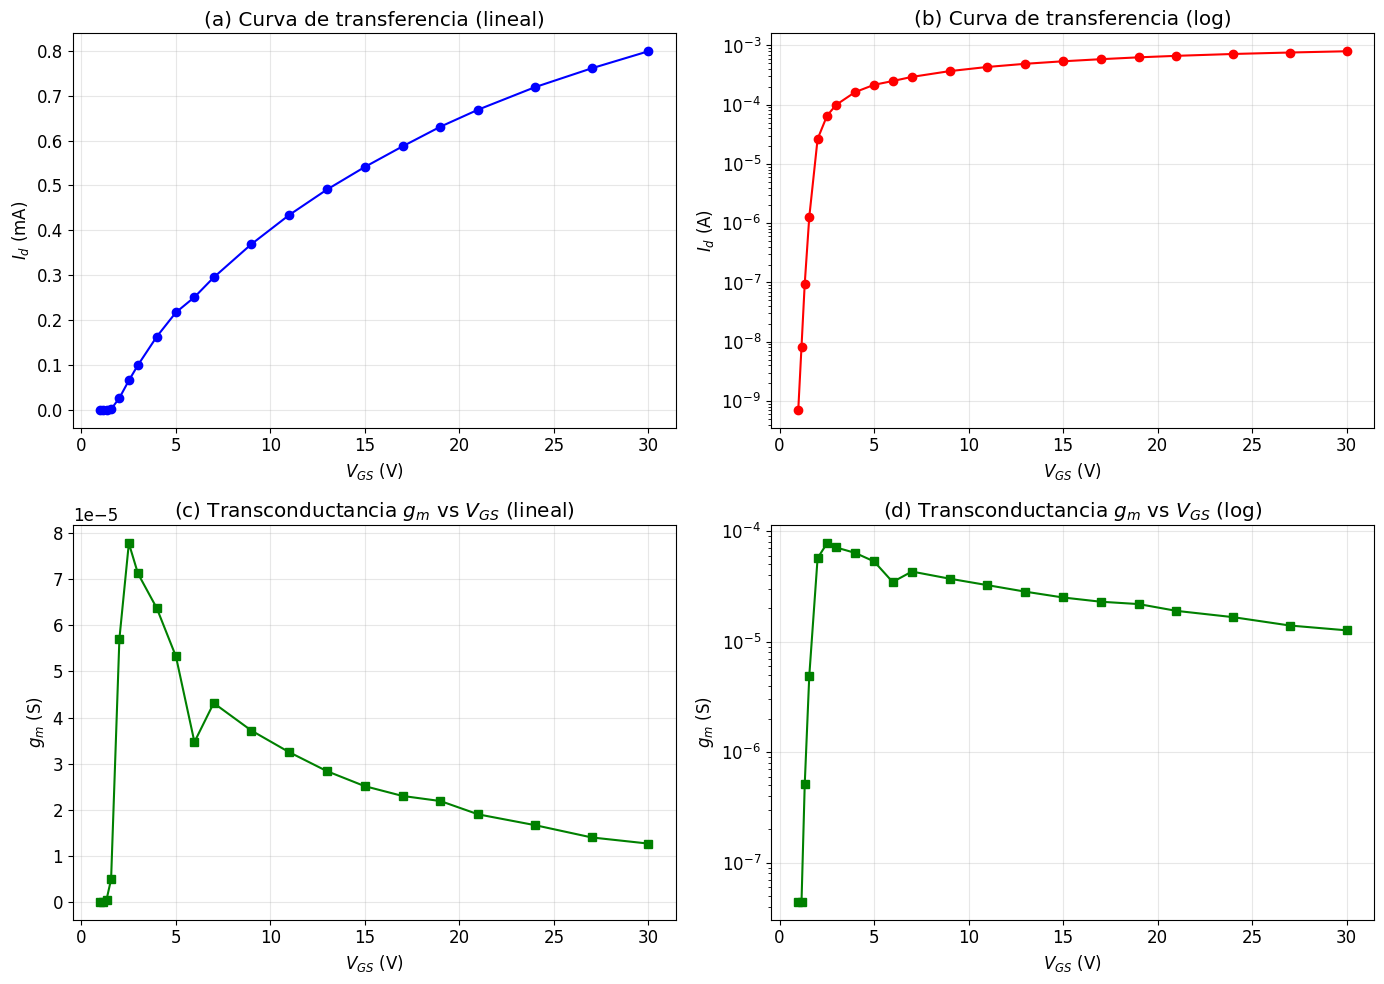

In [4]:
# ==========================================
# PLOTS: IDS-VGS curve, sensitivity and gm
# ==========================================
VGS_plot = np.array([m['VGS'] for m in medidas.values()])
Id_plot  = np.array([m['Id']  for m in medidas.values()])
gm_plot  = np.array([m['gm']  for m in medidas.values()])
K_plot   = np.array([m['K']   for m in medidas.values()])
Vout_plot = Id_plot * K_plot  # Vout = Id · K

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- (a) Id vs VGS linear ---
ax = axes[0, 0]
ax.plot(VGS_plot, Id_plot * 1e3, 'bo-', ms=6, lw=1.5)
ax.set_xlabel('$V_{GS}$ (V)')
ax.set_ylabel('$I_d$ (mA)')
ax.set_title('(a) Transfer curve (linear)')

# --- (b) Id vs VGS logarithmic ---
ax = axes[0, 1]
ax.semilogy(VGS_plot, Id_plot, 'ro-', ms=6, lw=1.5)
ax.set_xlabel('$V_{GS}$ (V)')
ax.set_ylabel('$I_d$ (A)')
ax.set_title('(b) Transfer curve (log)')

# --- (c) gm vs VGS ---
ax = axes[1, 0]
ax.plot(VGS_plot, gm_plot, 'gs-', ms=6, lw=1.5)
ax.set_xlabel('$V_{GS}$ (V)')
ax.set_ylabel('$g_m$ (S)')
ax.set_title('(c) Transconductance $g_m$ vs $V_{GS}$ (linear)')

# --- (d) gm vs VGS ---
ax = axes[1, 1]
ax.semilogy(VGS_plot, gm_plot, 'gs-', ms=6, lw=1.5)
ax.set_xlabel('$V_{GS}$ (V)')
ax.set_ylabel('$g_m$ (S)')
ax.set_title('(d) Transconductance $g_m$ vs $V_{GS}$ (log)')

plt.tight_layout()
plt.show()



## 4. Spectra $S_{I_d}(f)$

Each curve represents the power spectral density of current fluctuations for a different value of $V_{GS}$.
A $1/f$ behaviour is expected at low frequencies.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(espectros)))

for i, (nombre, S_Id) in enumerate(espectros.items()):
    vgs = medidas[nombre]['VGS']
    Id  = medidas[nombre]['Id']
    ax.loglog(freq, S_Id, color=colors[i], lw=1.2,
              label=f'{nombre}: $V_{{GS}}$={vgs:.1f}V, $I_d$={Id:.2e}A')

# 1/f reference
f_ref = np.logspace(np.log10(freq[1]), np.log10(freq[-1]), 100)
first_key = list(espectros.keys())[0]
A_ref = espectros[first_key][10] * freq[10]
ax.loglog(f_ref, A_ref / f_ref, 'k--', alpha=0.5, lw=1, label='$1/f$ reference')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('$S_{I_d}$ (A²/Hz)')
ax.set_title('Power Spectral Density of Drain Current Noise')
ax.legend(fontsize=9, loc='best')
ax.set_xlim([freq[1], freq[-1]])
plt.tight_layout()
plt.savefig('../figures/spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Extraction of $S_{I_d}/I_d^2$ at $f = 0.06$ Hz

The normalised spectral density is extracted at a fixed frequency to compare it with theoretical models.

In [ ]:
'''
f_target = 0.
idx_target = np.argmin(np.abs(freq - f_target))
f_real = freq[idx_target]
print('\nValues at target frequency: freq[0] = 0.015625 Hz, freq[1] = 0.046875 Hz, freq[2] = 0.078125 Hz')
print(f'The HP 35670A FFT analyser has a resolution of Δf = {deltaX:.5f} Hz.')
print(f'Target frequency: {f_target} Hz → Actual frequency: {f_real:.6f} Hz (idx={idx_target})')

Id_arr, SId_norm_arr, gm_arr, VGS_arr, names = [], [], [], [], []
for nombre, S_Id in espectros.items():
    Id  = medidas[nombre]['Id']
    gm  = medidas[nombre]['gm']
    vgs = medidas[nombre]['VGS']
    SId_f = S_Id[idx_target]
    SId_n = SId_f / Id**2
    Id_arr.append(Id); SId_norm_arr.append(SId_n)
    gm_arr.append(gm); VGS_arr.append(vgs); names.append(nombre)
    print(f'  {nombre}: VGS={vgs:.1f}V, Id={Id:.2e}A, SId/Id²={SId_n:.2e} Hz⁻¹')

Id_arr = np.array(Id_arr)
SId_norm_arr = np.array(SId_norm_arr)
gm_arr = np.array(gm_arr)
VGS_arr = np.array(VGS_arr)
'''

# WITH INTERPOLATION
# ==========================================
# EXTRACTION OF SId/Id² WITH 1/f FIT
# ==========================================
f_target = 1

Id_arr, SId_norm_arr, gm_arr, VGS_arr, names = [], [], [], [], []

fig, axes = plt.subplots(3, 7, figsize=(24, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx_esp, (nombre, S_Id) in enumerate(espectros.items()):
    Id  = medidas[nombre]['Id']
    gm  = medidas[nombre]['gm']
    vgs = medidas[nombre]['VGS']
    
    # Select 1/f region: low frequencies where the spectrum follows 1/f
    # Fit S = A / f^beta in log-log: log(S) = log(A) - beta·log(f)
    # Try different ranges and choose where beta ≈ 1
    f_min, f_max = 0.5, 6.0  # initial range for the fit
    mask_fit = (freq >= f_min) & (freq <= f_max)
    
    log_f = np.log10(freq[mask_fit])
    log_S = np.log10(S_Id[mask_fit])
    
    # Linear fit in log-log: log(S) = a + b·log(f)
    coeffs = np.polyfit(log_f, log_S, 1)
    beta = -coeffs[0]  # slope (should be ~1 for 1/f)
    
    # Value extrapolated to f_target
    SId_fit = 10**(coeffs[0] * np.log10(f_target) + coeffs[1])
    SId_n = SId_fit / Id**2
    
    Id_arr.append(Id); SId_norm_arr.append(SId_n)
    gm_arr.append(gm); VGS_arr.append(vgs); names.append(nombre)
    
    # Mini-plot for each trace
    if idx_esp < len(axes):
        ax = axes[idx_esp]
        ax.loglog(freq, S_Id, 'b-', lw=0.5, alpha=0.5)
        ax.loglog(freq[mask_fit], S_Id[mask_fit], 'b-', lw=1.5)  # region used
        f_line = np.logspace(np.log10(0.01), np.log10(freq[-1]), 50)
        ax.loglog(f_line, 10**(coeffs[0]*np.log10(f_line)+coeffs[1]), 'r--', lw=1.5)
        ax.axvline(x=f_target, color='green', ls=':', alpha=0.5)
        ax.set_title(f'{nombre}\nβ={beta:.2f}', fontsize=9)
        ax.tick_params(labelsize=7)

Id_arr = np.array(Id_arr)
SId_norm_arr = np.array(SId_norm_arr)
gm_arr = np.array(gm_arr)
VGS_arr = np.array(VGS_arr)

# Hide empty subplots
for j in range(len(espectros), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('$1/f^\\beta$ fit per trace (red=fit, thick blue=region used, green=target f)', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/transfer_curve.png', dpi=150, bbox_inches='tight')
plt.savefig('../figures/spectral_fits.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f'{"Traza":>8s} {"VGS":>7s} {"Id":>10s} {"β":>6s} {"SId/Id²":>12s}')
print('-' * 50)
for i, nombre in enumerate(names):
    # Recompute beta for display
    mask_f = (freq >= 0.02) & (freq <= 2.0)
    S_Id = espectros[nombre]
    c = np.polyfit(np.log10(freq[mask_f]), np.log10(S_Id[mask_f]), 1)
    print(f'{nombre:>8s} {VGS_arr[i]:7.2f} {Id_arr[i]:10.2e} {-c[0]:6.2f} {SId_norm_arr[i]:12.3e}')

print(f'\nEvaluation frequency: {f_target} Hz (interpolated from 1/f fit)')

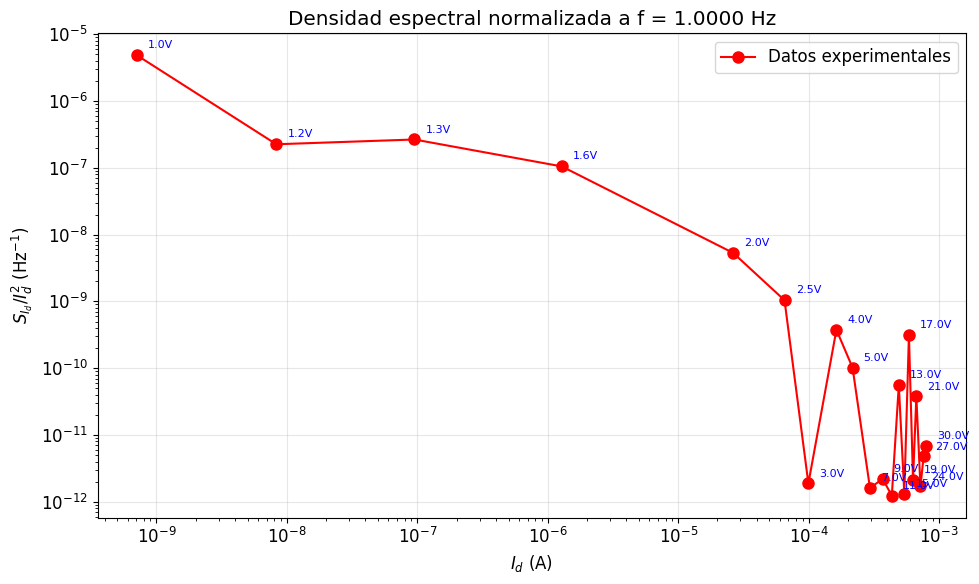

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(Id_arr, SId_norm_arr, 'ro-', ms=8, lw=1.5, label='Experimental data')

for i in range(len(names)):
    ax.annotate(f'{VGS_arr[i]:.1f}V', (Id_arr[i], SId_norm_arr[i]),
                textcoords='offset points', xytext=(8, 5), fontsize=8, color='blue')

ax.set_xlabel('$I_d$ (A)')
ax.set_ylabel('$S_{I_d}/I_d^2$ (Hz$^{-1}$)')
f_real = f_target
ax.set_title(f'Normalised spectral density at f = {f_real:.4f} Hz')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/normalized_noise.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. McWhorter Model Without Mobility Correlation

$$\frac{S_{I_d}}{I_d^2} = \frac{g_m^2}{I_d^2} \cdot S_{V_{FB}}$$

We fit $S_{V_{FB}}$ as a free parameter.

S_VFB (ajuste) = 2.1861e-09 V²/Hz


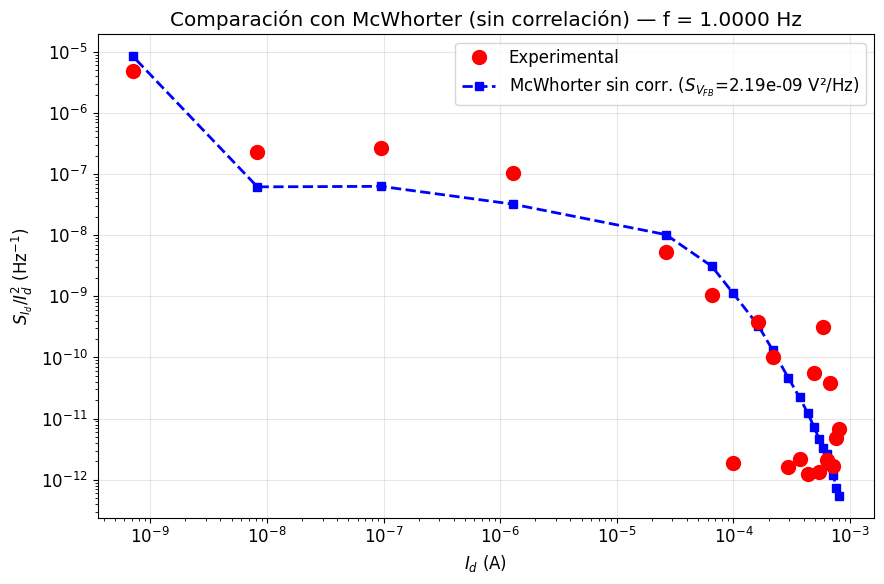

In [8]:
# FIT S_VFB
gm_Id_sq = (gm_arr / Id_arr)**2

def res_svfb(log_svfb):
    model = gm_Id_sq * 10**log_svfb
    return np.sum((np.log10(SId_norm_arr) - np.log10(model))**2)

res = minimize_scalar(res_svfb, bounds=(-20, 0), method='bounded')
S_VFB = 10**res.x 
model_nocorr = gm_Id_sq * S_VFB

print(f'S_VFB (fit) = {S_VFB:.4e} V²/Hz')

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(Id_arr, SId_norm_arr, 'ro', ms=10, label='Experimental', zorder=5)
ax.loglog(Id_arr, model_nocorr, 'b--s', lw=2, ms=6,
          label=f'McWhorter no corr. ($S_{{V_{{FB}}}}$={S_VFB:.2e} V²/Hz)')
ax.set_xlabel('$I_d$ (A)')
ax.set_ylabel('$S_{I_d}/I_d^2$ (Hz$^{-1}$)')
ax.set_title(f'Comparison with McWhorter (no correlation) — f = {f_real:.4f} Hz')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/mcwhorter_nocorr.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. McWhorter Model With Mobility Correlation

$$\frac{S_{I_d}}{I_d^2} = \left(1 + \alpha \mu_{eff} C_{ox} \frac{I_d}{g_m}\right)^2 \frac{g_m^2}{I_d^2} \cdot S_{V_{FB}}$$

We use $S_{V_{FB}}$ from the previous fit and adjust $\alpha$.

alpha = 1.33e+02 V·s/C
S_VFB = 2.19e-09 V²/Hz (fijado)


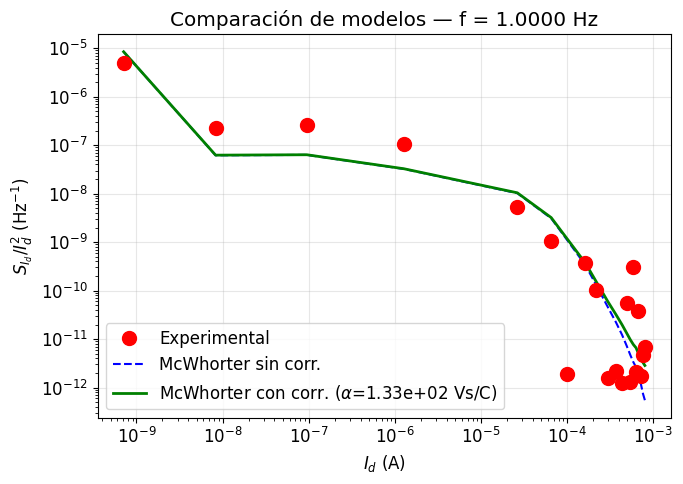

In [9]:
def mcwhorter_corr(Id, gm, svfb, alpha):
    factor = (1 + alpha * mu * C_ox * Id / gm)**2
    return factor * (gm / Id)**2 * svfb

def res_alpha(log_alpha):
    alpha = 10**log_alpha
    model = np.array([mcwhorter_corr(Id_arr[i], gm_arr[i], S_VFB, alpha) for i in range(len(Id_arr))])
    return np.sum((np.log10(SId_norm_arr) - np.log10(model))**2)

res_a = minimize_scalar(res_alpha, bounds=(0, 8), method='bounded')
alpha_fit = 10**res_a.x 
model_corr = np.array([mcwhorter_corr(Id_arr[i], gm_arr[i], S_VFB, alpha_fit) for i in range(len(Id_arr))])

print(f'alpha = {alpha_fit:.2e} V·s/C')
print(f'S_VFB = {S_VFB:.2e} V²/Hz (fixed)')

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(Id_arr, SId_norm_arr, 'ro', ms=10, label='Experimental', zorder=5)
ax.loglog(Id_arr, model_nocorr, 'b--', lw=1.5, label='McWhorter no corr.')
ax.loglog(Id_arr, model_corr, 'g-', lw=2,
          label=f'McWhorter with corr. ($\\alpha$={alpha_fit:.2e} Vs/C)')
ax.set_xlabel('$I_d$ (A)')
ax.set_ylabel('$S_{I_d}/I_d^2$ (Hz$^{-1}$)')
ax.set_title(f'Model comparison — f = {f_real:.4f} Hz')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/mcwhorter_corr.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Extraction of Trap Density $N_T(E_f)_{eff}$

$$N_T(E_f)_{eff} = \frac{S_{V_{FB}} \cdot f \cdot W \cdot L \cdot C_{ox}^2 \cdot \gamma}{q^2 \cdot kT}$$

In [10]:
# S_VFB is already evaluated at f_real (contains the 1/f factor)
S_VFB_x_f = S_VFB * f_real  # S_VFB(f)·f = q²·NT·kT / (W·L·Cox²·γ)

NT_SI = S_VFB_x_f * W * L * C_ox**2 * gamma / (q**2 * kT)  # [m⁻³ J⁻¹]
NT_cgs = NT_SI * 1e-6 * q  # [cm⁻³ eV⁻¹]

print('=' * 55)
print('  OXIDE TRAP DENSITY')
print('=' * 55)
print(f'  S_VFB          = {S_VFB:.4e} V²/Hz  (at f={f_real:.4f} Hz)')
print(f'  S_VFB · f      = {S_VFB_x_f:.4e} V²')
print(f'  N_T(Ef)_eff    = {NT_SI:.4e} m⁻³·J⁻¹')
print(f'  N_T(Ef)_eff    = {NT_cgs:.4e} cm⁻³·eV⁻¹')
print('=' * 55)

  DENSIDAD DE TRAMPAS EN EL ÓXIDO
  S_VFB          = 2.1861e-09 V²/Hz  (a f=1.0000 Hz)
  S_VFB · f      = 2.1861e-09 V²
  N_T(Ef)_eff    = 1.7814e+43 m⁻³·J⁻¹
  N_T(Ef)_eff    = 2.8539e+18 cm⁻³·eV⁻¹


## 9. $S_{V_g}$ vs $V_{GS}$

$S_{V_g} = (S_{I_d}/I_d^2) \cdot (I_d/g_m)^2$

- Without correlation: $S_{V_g} \approx S_{V_{FB}}$ = const.
- With correlation: parabolic dependence on $V_{GS}$.

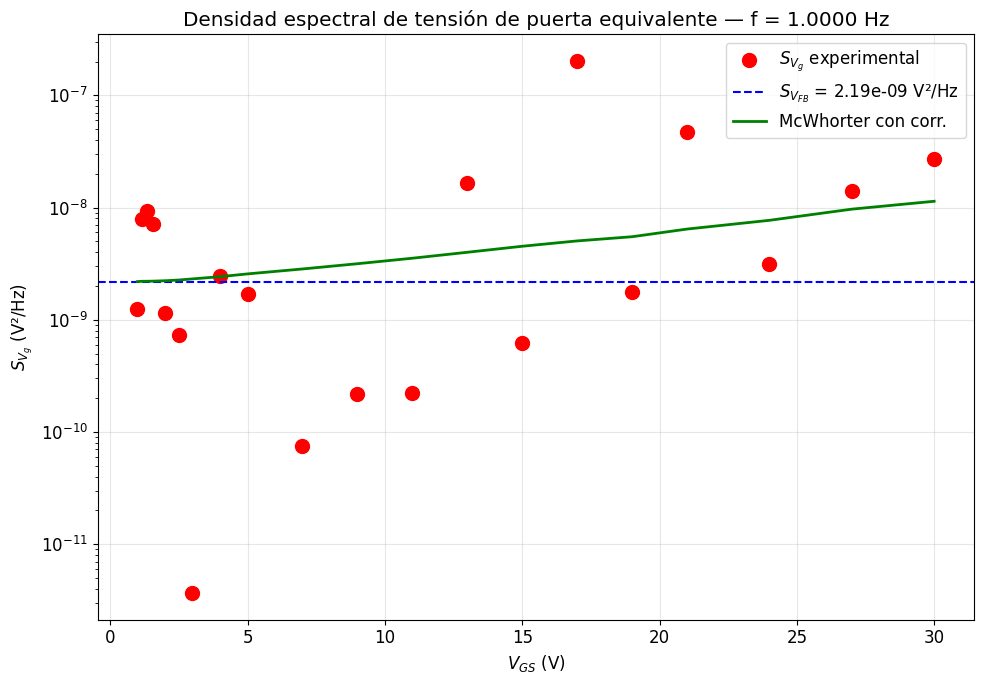

In [11]:
S_Vg_exp = SId_norm_arr * (Id_arr / gm_arr)**2
S_Vg_corr = np.array([(1 + alpha_fit * mu * C_ox * Id_arr[i] / gm_arr[i])**2 * S_VFB
                        for i in range(len(Id_arr))])

fig, ax = plt.subplots(figsize=(10, 7))
ax.semilogy(VGS_arr, S_Vg_exp, 'ro', ms=10, label='$S_{V_g}$ experimental')
ax.axhline(y=S_VFB, color='b', ls='--', lw=1.5, label=f'$S_{{V_{{FB}}}}$ = {S_VFB:.2e} V²/Hz')
ax.semilogy(VGS_arr, S_Vg_corr, 'g-', lw=2, label=f'McWhorter with corr.')
ax.set_xlabel('$V_{GS}$ (V)')
ax.set_ylabel('$S_{V_g}$ (V²/Hz)')
ax.set_title(f'Equivalent gate voltage spectral density — f = {f_real:.4f} Hz')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/gate_voltage_noise.png', dpi=150, bbox_inches='tight')
plt.show()